# UCI Secom Analysis

## 데이터셋 설명
본 과제는 UCI Machine Learning Repository에 공개된 SECOM(Semiconductor Manufacturing Process) 데이터셋을 사용합니다.

## 과제 목적
반도체 제조 공정은 수백 개의 센서가 실시간으로 측정하는 복잡한 공정 변수들로 구성되며, 최종 제품의 수율(Yield)은 이 변수들의 상호작용에 의해 결정됩니다. 본 과제는 실제 반도체 제조 공정 데이터(SECOM)의 590개 센서 피처를 분석하여 웨이퍼의 불량 여부를 사전에 예측하는 분류 모델을 구축하는 것을 목적으로 합니다.

•	불량 웨이퍼 조기 탐지: 공정 완료 전 불량을 예측하여 후공정 비용 절감 및 수율 향상  
•	불균형 데이터 처리 방법론 비교: 극심한 클래스 불균형(불량 93.4% vs. 양품 6.6%) 환경에서 효과적인 oversampling 기법 및 평가 지표 탐구  


## 적용하고자 하는 방법
### 1단계 · 데이터 탐색 및 전처리 (EDA & Preprocessing)
•	EDA: 1,567개 웨이퍼 × 590개 센서 피처의 분포, 이상치, 타겟 변수 비율(Pass/Fail) 시각화  
**Train / Test Split** (비율 80:20, `stratify=y` 적용)
    
- **고비율 결측 피처 제거** (예: 45% 이상 결측치인 열 Drop)
    
- **결측치 대치** (KNN Imputer, K=5)
    
- **무의미한 피처 제거** (분산이 0인 피처 제거)
    
- **스케일링** (RobustScaler) - `RobustScaler`는 중앙값(Median)과 사분위수(IQR)를 사용하므로 이상치의 영향을 최소화하면서 안정적으로 데이터를 정규화
    
- **다중공선성 제거** (피어슨 상관계수 0.85 기준, Target과의 상관관계 비교를 통한 Smart Drop 적용) 


### 1단계 · 데이터 탐색 및 전처리 (EDA & Preprocessing)

원본 shape: (1567, 592)
컬럼 목록 앞부분: ['Time', '0', '1', '2', '3'] ... ['588', '589', 'Pass/Fail']

[타겟 분포]
           count  pct(%)
Pass/Fail               
-1          1463   93.36
 1           104    6.64


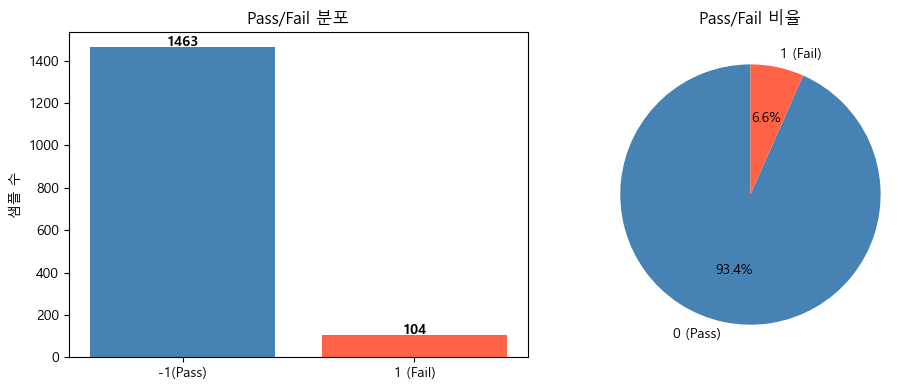

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler

plt.rcParams['font.family'] = 'Malgun Gothic'  # 한글 폰트
plt.rcParams['axes.unicode_minus'] = False

# ──────────────────────────────────────────
# 1. 데이터 로드
# ──────────────────────────────────────────
df = pd.read_csv("uci-secom.csv")
print(f"원본 shape: {df.shape}")          # (1567, 592)
print(f"컬럼 목록 앞부분: {df.columns[:5].tolist()} ... {df.columns[-3:].tolist()}")

# ──────────────────────────────────────────
# 2. EDA
# ──────────────────────────────────────────

# 2-1. 타겟 분포 (Pass/Fail 비율)
label_counts = df['Pass/Fail'].value_counts()
label_pct = df['Pass/Fail'].value_counts(normalize=True) * 100
print("\n[타겟 분포]")
print(pd.DataFrame({'count': label_counts, 'pct(%)': label_pct.round(2)}))

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
axes[0].bar(['-1(Pass)', '1 (Fail)'], label_counts.values, color=['steelblue', 'tomato'])
axes[0].set_title('Pass/Fail 분포')
axes[0].set_ylabel('샘플 수')
for i, v in enumerate(label_counts.values):
    axes[0].text(i, v + 5, str(v), ha='center', fontweight='bold')

axes[1].pie(label_counts.values, labels=['0 (Pass)', '1 (Fail)'],
            autopct='%1.1f%%', colors=['steelblue', 'tomato'], startangle=90)
axes[1].set_title('Pass/Fail 비율')
plt.tight_layout()
plt.show()

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.impute import SimpleImputer

plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False




[결측치 요약]
  전체 결측값 수     : 41,951
  결측값 있는 피처 수: 538 / 590
  결측률 50% 초과    : 28개 피처
  결측률 90% 초과    : 4개 피처

결측률 상위 10개 피처:
feature  missing_count  missing_ratio
    292           1429      91.193363
    293           1429      91.193363
    158           1429      91.193363
    157           1429      91.193363
    492           1341      85.577537
     85           1341      85.577537
    358           1341      85.577537
    220           1341      85.577537
    244           1018      64.964901
    517           1018      64.964901


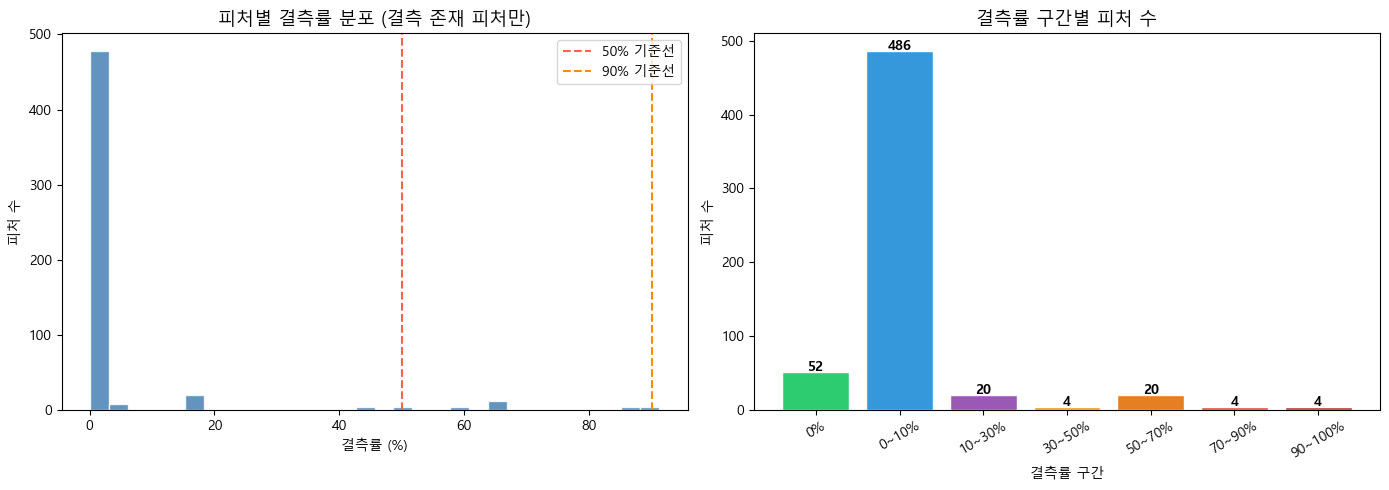

In [2]:
# ──────────────────────────────────────────
# 3. 결측치 분석
# ──────────────────────────────────────────

feature_cols = [c for c in df.columns if c not in ['Time', 'Pass/Fail']]

# 3-1. 피처별 결측치 비율 계산
missing_ratio = df[feature_cols].isnull().mean() * 100
missing_counts = df[feature_cols].isnull().sum()

missing_df = pd.DataFrame({
    'feature': feature_cols,
    'missing_count': missing_counts.values,
    'missing_ratio': missing_ratio.values
}).sort_values('missing_ratio', ascending=False).reset_index(drop=True)

print(f"\n[결측치 요약]")
print(f"  전체 결측값 수     : {missing_counts.sum():,}")
print(f"  결측값 있는 피처 수: {(missing_counts > 0).sum()} / {len(feature_cols)}")
print(f"  결측률 50% 초과    : {(missing_ratio > 50).sum()}개 피처")
print(f"  결측률 90% 초과    : {(missing_ratio > 90).sum()}개 피처")
print(f"\n결측률 상위 10개 피처:")
print(missing_df.head(10).to_string(index=False))

# 3-2. 결측률 구간별 히스토그램
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 히스토그램: 결측률 분포
axes[0].hist(missing_ratio[missing_ratio > 0], bins=30,
             color='steelblue', edgecolor='white', alpha=0.85)
axes[0].set_title('피처별 결측률 분포 (결측 존재 피처만)', fontsize=13)
axes[0].set_xlabel('결측률 (%)')
axes[0].set_ylabel('피처 수')
axes[0].axvline(50, color='tomato', linestyle='--', linewidth=1.5, label='50% 기준선')
axes[0].axvline(90, color='darkorange', linestyle='--', linewidth=1.5, label='90% 기준선')
axes[0].legend()

# 막대그래프: 결측률 구간별 피처 수
bins_labels = ['0%', '0~10%', '10~30%', '30~50%', '50~70%', '70~90%', '90~100%']
bin_counts = [
    (missing_ratio == 0).sum(),
    ((missing_ratio > 0)  & (missing_ratio <= 10)).sum(),
    ((missing_ratio > 10) & (missing_ratio <= 30)).sum(),
    ((missing_ratio > 30) & (missing_ratio <= 50)).sum(),
    ((missing_ratio > 50) & (missing_ratio <= 70)).sum(),
    ((missing_ratio > 70) & (missing_ratio <= 90)).sum(),
    ((missing_ratio > 90) & (missing_ratio <= 100)).sum(),
]
colors = ['#2ecc71', '#3498db', '#9b59b6', '#f39c12', '#e67e22', '#e74c3c', '#c0392b']
bars = axes[1].bar(bins_labels, bin_counts, color=colors, edgecolor='white')
axes[1].set_title('결측률 구간별 피처 수', fontsize=13)
axes[1].set_xlabel('결측률 구간')
axes[1].set_ylabel('피처 수')
axes[1].tick_params(axis='x', rotation=30)
for bar, cnt in zip(bars, bin_counts):
    if cnt > 0:
        axes[1].text(bar.get_x() + bar.get_width() / 2,
                     bar.get_height() + 1, str(cnt),
                     ha='center', fontweight='bold', fontsize=10)

plt.tight_layout()
plt.show()



### Data preprocessing

### 1. Train/Test Split

In [3]:
from sklearn.model_selection import train_test_split

X = df.drop(columns=["Time", "Pass/Fail"])
y = df["Pass/Fail"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Train: {X_train.shape}, Test: {X_test.shape}")
print(f"Train 불량 비율: {(y_train == -1).mean():.3f}")
print(f"Test  불량 비율: {(y_test == -1).mean():.3f}")

Train: (1253, 590), Test: (314, 590)
Train 불량 비율: 0.934
Test  불량 비율: 0.933


### 2. KNN Imputer

In [4]:
from sklearn.impute import KNNImputer
import pandas as pd

imputer = KNNImputer(n_neighbors=5)

X_train_imputed = imputer.fit_transform(X_train)
X_test_imputed  = imputer.transform(X_test)

X_train = pd.DataFrame(X_train_imputed, columns=X_train.columns)
X_test  = pd.DataFrame(X_test_imputed,  columns=X_test.columns)

print(f"결측치 확인 - Train: {X_train.isna().sum().sum()}, Test: {X_test.isna().sum().sum()}")

결측치 확인 - Train: 0, Test: 0


### 3. 분산 0 피처 제거

In [5]:
zero_var_cols = X_train.columns[X_train.var() == 0].tolist()

X_train = X_train.drop(columns=zero_var_cols)
X_test  = X_test.drop(columns=zero_var_cols)

print(f"제거된 피처 수: {len(zero_var_cols)}")
print(f"남은 피처 수: {X_train.shape[1]}")

제거된 피처 수: 116
남은 피처 수: 474


### 4. Robust Scaler

In [6]:
from sklearn.preprocessing import RobustScaler

scaler = RobustScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

X_train = pd.DataFrame(X_train_scaled, columns=X_train.columns)
X_test  = pd.DataFrame(X_test_scaled,  columns=X_test.columns)

### 5. multicollinearity 제거 ( Smart Drop)

In [7]:
import numpy as np

THRESHOLD = 0.85

# Target과 각 피처의 상관계수 (절댓값) - train 기준
y_train_arr = y_train.reset_index(drop=True)
target_corr = X_train.apply(lambda col: col.corr(y_train_arr)).abs()

# 피처 간 상관계수 행렬
corr_matrix = X_train.corr().abs()

# 상삼각 행렬에서 threshold 초과 쌍 추출
upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))

cols_to_drop = set()
for col in upper.columns:
    high_corr_features = upper.index[upper[col] > THRESHOLD].tolist()
    for feature in high_corr_features:
        # target 상관관계가 더 낮은 쪽 제거
        if target_corr[col] < target_corr[feature]:
            cols_to_drop.add(col)
        else:
            cols_to_drop.add(feature)

X_train = X_train.drop(columns=list(cols_to_drop))
X_test  = X_test.drop(columns=list(cols_to_drop))

print(f"제거된 피처 수: {len(cols_to_drop)}")
print(f"최종 피처 수: {X_train.shape[1]}")

제거된 피처 수: 230
최종 피처 수: 244


In [8]:
import pandas as pd

train_df = X_train.copy()
train_df["Pass/Fail"] = y_train.values
train_df["split"] = "train"

test_df = X_test.copy()
test_df["Pass/Fail"] = y_test.values
test_df["split"] = "test"

preprocessed = pd.concat([train_df, test_df], axis=0)
preprocessed.to_csv("secom_preprocessed.csv", index=False)

print(f"저장 완료: {preprocessed.shape}")
print(f"Train: {(preprocessed['split'] == 'train').sum()}, Test: {(preprocessed['split'] == 'test').sum()}")

저장 완료: (1567, 246)
Train: 1253, Test: 314
